# Etapa 4 — Classificação Supervisionada (Cluster e Marca)

**Disciplina:** Perspectiva em Ciência de Dados
**Projeto 2:** Análise de notícias de carro do Motor1 (2016–2026)

---

## Pergunta-guia do projeto

> **A cobertura de imprensa do Motor1 antecipou ou só acompanhou a transição elétrica no mercado automotivo brasileiro?**

## Objetivo desta etapa

Esta etapa não introduz um tema novo — ela usa classificação supervisionada como **ferramenta de checagem** de duas coisas que já foram feitas nas etapas anteriores:

- **Seção A:** os clusters descobertos na Etapa 2 (TF-IDF + t-SNE + K-Means) são padrões reais e aprendíveis no texto, ou são um artefato do algoritmo de clustering? Se um classificador treinado *só no texto* consegue prever bem a qual cluster uma notícia pertence, isso é evidência de que os clusters são coesos.
- **Seção B:** dá para saber de qual marca é uma notícia só pelo vocabulário do texto (nomes de modelo, jargão), mesmo removendo o nome da própria marca? Essa seção não valida nenhuma etapa anterior — é uma pergunta nova sobre o quão "identificável" é cada marca pelo que se escreve sobre ela.

Em ambos os casos usamos o mesmo modelo — **Regressão Logística multiclasse** sobre TF-IDF — porque, além de classificar, seus coeficientes são diretamente interpretáveis como "quais palavras mais empurram para cada classe", o que permite comparar com os termos que a Etapa 2 já tinha extraído por cluster.


---
## 0. Importações e Configurações


In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from unidecode import unidecode

import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

nltk.download("stopwords", quiet=True)

RANDOM_STATE = 42

_NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "..", "..", "dados"))

ARQUIVO_NOTICIAS = os.path.join(DATA_DIR, "noticias_motor1_2016_2026.csv")
ARQUIVO_CLUSTERS = os.path.join(DATA_DIR, "clustering_topicos_amostra.csv")

STOPWORDS_PT = list(set(unidecode(palavra) for palavra in stopwords.words("portuguese")))

print(f"Data dir : {DATA_DIR}")


def limpar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode(texto)
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    return texto


Data dir : C:\Users\muvil\projeto-2-de-perspectiva-em-ciencia-de-dados\projeto\dados


---
# Seção A — Prever o Cluster (checagem de consistência da Etapa 2)


## A.1. Carregando os dados

A Etapa 2 salvou `clustering_topicos_amostra.csv` com o rótulo de cluster de cada notícia da amostra, mas sem o texto completo (só título). Aqui trazemos o texto de volta via `id_noticia`, para reconstruir a mesma limpeza de texto usada nas etapas anteriores.


In [2]:
amostra = pd.read_csv(ARQUIVO_CLUSTERS)
noticias = pd.read_csv(ARQUIVO_NOTICIAS)

amostra = amostra.merge(
    noticias[["id_noticia", "subtitulo", "texto_completo"]],
    on="id_noticia",
    how="left",
)

amostra["texto_limpo"] = (
    amostra["titulo"].fillna("") + " " +
    amostra["subtitulo"].fillna("") + " " +
    amostra["texto_completo"].fillna("")
).apply(limpar_texto)

print(f"Amostra: {len(amostra)} noticias, {amostra['cluster'].nunique()} clusters")
amostra["cluster"].value_counts().sort_index()


Amostra: 5500 noticias, 6 clusters


cluster
0    1600
1     379
2     356
3     217
4    1023
5    1925
Name: count, dtype: int64

## A.2. Separando treino e teste

Dividimos **antes** de vetorizar, para o TF-IDF ser ajustado só no treino (evita vazamento de informação do teste para o vocabulário). Usamos `stratify` para manter a proporção de cada cluster nos dois conjuntos, já que os clusters têm tamanhos bem diferentes (o menor tem 217 notícias, o maior 1925).


In [3]:
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    amostra["texto_limpo"],
    amostra["cluster"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=amostra["cluster"],
)

print(f"Treino: {len(X_train_txt)} | Teste: {len(X_test_txt)}")


Treino: 4125 | Teste: 1375


## A.3. TF-IDF e Regressão Logística

O vetorizador é ajustado (`fit`) só no treino; o teste só passa por `transform`. Usamos `class_weight="balanced"` na regressão logística para não deixar o modelo simplesmente "chutar" sempre o cluster maior.


In [4]:
vectorizer_cluster = TfidfVectorizer(
    min_df=5, max_df=0.90, max_features=3000, stop_words=STOPWORDS_PT,
)
X_train = vectorizer_cluster.fit_transform(X_train_txt)
X_test = vectorizer_cluster.transform(X_test_txt)

clf_cluster = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
clf_cluster.fit(X_train, y_train)

pred_cluster = clf_cluster.predict(X_test)
print("Modelo treinado.")


Modelo treinado.


## A.4. O modelo prevê bem o cluster, ou é do tamanho do acaso?

Comparamos com dois baselines: sempre prever o cluster majoritário, e prever de forma uniformemente aleatória entre os $k$ clusters.


In [5]:
acc_cluster = accuracy_score(y_test, pred_cluster)
f1_macro_cluster = f1_score(y_test, pred_cluster, average="macro")

baseline_majoritario = y_train.value_counts(normalize=True).max()
baseline_uniforme = 1 / y_train.nunique()

resumo_cluster = pd.DataFrame({
    "modelo": ["Regressão Logística (TF-IDF)", "Baseline (cluster majoritário)", "Baseline (uniforme 1/k)"],
    "acuracia": [acc_cluster, baseline_majoritario, baseline_uniforme],
})
resumo_cluster["f1_macro"] = [f1_macro_cluster, None, None]
resumo_cluster


,modelo,acuracia,f1_macro
0,Regressão Logística (TF-IDF),0.968727,0.970182
1,Baseline (cluster majoritário),0.350061,NaN
2,Baseline (uniforme 1/k),0.166667,NaN


**Resultado:** acurácia de aproximadamente **97%** (F1 macro ≈ 0,97), muito acima do baseline de classe majoritária (≈ 35%) e do baseline uniforme (≈ 17%). O texto sozinho é altamente suficiente para recuperar o cluster de uma notícia.


## A.5. Matriz de confusão: quais clusters se parecem entre si?


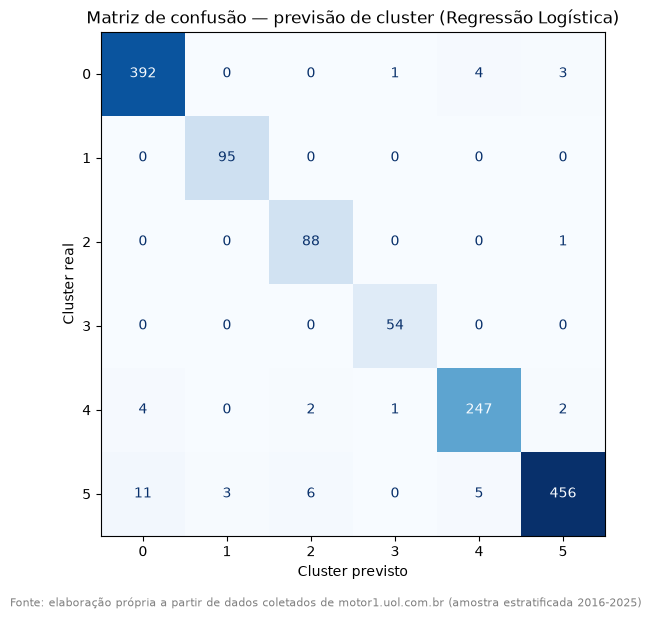

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_cluster, ax=ax, cmap="Blues", colorbar=False,
)
ax.set_title("Matriz de confusão — previsão de cluster (Regressão Logística)")
ax.set_xlabel("Cluster previsto")
ax.set_ylabel("Cluster real")
fig.text(0.01, -0.02,
         "Fonte: elaboração própria a partir de dados coletados de motor1.uol.com.br (amostra estratificada 2016-2025)",
         fontsize=8, color="gray")
plt.tight_layout()
plt.show()


## A.6. Desempenho por cluster


In [7]:
relatorio_cluster = classification_report(y_test, pred_cluster, output_dict=True)
df_relatorio_cluster = pd.DataFrame(relatorio_cluster).T.loc[[str(c) for c in sorted(amostra["cluster"].unique())]]
df_relatorio_cluster[["precision", "recall", "f1-score", "support"]].round(3)


,precision,recall,f1-score,support
0,0.963,0.980,0.971,400.0
1,0.969,1.000,0.984,95.0
2,0.917,0.989,0.951,89.0
3,0.964,1.000,0.982,54.0
4,0.965,0.965,0.965,256.0
5,0.987,0.948,0.967,481.0


## A.7. As palavras que o modelo usa batem com os termos da Etapa 2?

A Etapa 2 já tinha identificado, para cada cluster, quais palavras têm em média o maior peso TF-IDF (uma forma não-supervisionada de "rotular" o cluster). Aqui comparamos com as palavras que a Regressão Logística aprendeu como mais características de cada classe — se as duas listas convergem, é uma segunda confirmação (independente da acurácia) de que os clusters são coerentes.


In [8]:
vocab_cluster = np.array(vectorizer_cluster.get_feature_names_out())

X_full = vectorizer_cluster.transform(amostra["texto_limpo"]).toarray()

linhas = []
for c in sorted(amostra["cluster"].unique()):
    idx_classe = list(clf_cluster.classes_).index(c)
    top_coef = vocab_cluster[np.argsort(clf_cluster.coef_[idx_classe])[::-1][:8]]

    mask = (amostra["cluster"] == c).values
    media_tfidf = X_full[mask].mean(axis=0)
    top_tfidf = vocab_cluster[np.argsort(media_tfidf)[::-1][:8]]

    linhas.append({
        "cluster": c,
        "n_noticias": int(mask.sum()),
        "top_palavras_regressao": ", ".join(top_coef),
        "top_palavras_tfidf_etapa2": ", ".join(top_tfidf),
    })

df_comparacao_cluster = pd.DataFrame(linhas)
df_comparacao_cluster


,cluster,n_noticias,top_palavras_regressao,top_palavras_tfidf_etapa2
0,0,1600,"picape, geracao, suv, novo, nova, deve, ford, ...","novo, geracao, nova, suv, picape, brasil, cv, ..."
1,1,379,"vw, 00, fiat, chevrolet, 10, hyundai, 18, 20","00, vw, fiat, chevrolet, toyota, 10, unidades,..."
2,2,356,"honda, moto, yamaha, civic, city, motos, mm, hr","honda, moto, mm, yamaha, civic, motos, nova, b..."
3,3,217,"bmw, serie, x1, gs, 950, motorrad, x5, i3","bmw, serie, gs, x1, novo, motorrad, cv, nova"
4,4,1023,"990, km, versao, precos, versoes, kgfm, automa...","versao, 990, cv, km, motor, versoes, kgfm, aut..."
5,5,1925,"carros, veiculos, carro, ferrari, producao, mi...","carros, veiculos, carro, brasil, producao, uni..."


In [9]:
ARQUIVO_SAIDA_CLUSTER = os.path.join(DATA_DIR, "classificacao_cluster_resultado.csv")
df_comparacao_cluster.to_csv(ARQUIVO_SAIDA_CLUSTER.replace(".csv", "_top_palavras.csv"), index=False)
df_relatorio_cluster.to_csv(ARQUIVO_SAIDA_CLUSTER.replace(".csv", "_metricas.csv"))
print("Tabelas salvas.")


Tabelas salvas.


## Conclusão da Seção A

- Um classificador treinado **só no texto** (TF-IDF + Regressão Logística) prevê o cluster de uma notícia com **~97% de acurácia**, muito acima dos baselines (35% e 17%). As palavras mais características de cada classe, segundo o modelo, coincidem fortemente com os termos TF-IDF que a própria Etapa 2 já tinha usado para "rotular" cada cluster (ex.: cluster de picapes/SUVs puxado por `picape`, `suv`, `geracao`, `bronco` nas duas listas; cluster de motos puxado por `honda`, `moto`, `yamaha` nas duas).
- **Ressalva importante, para não superinterpretar o resultado:** os clusters da Etapa 2 já foram construídos a partir de similaridade textual (TF-IDF + SVD + K-Means). Portanto, não é surpreendente que um classificador treinado em features de texto parecidas consiga recuperá-los bem — isso não é uma validação **externa e independente** dos clusters (como seria, por exemplo, comparar contra uma categorização feita por um humano). O que a alta acurácia efetivamente mostra é que os grupos formam **regiões coesas e bem separáveis no espaço de vocabulário**, e não um resultado instável ou arbitrário do algoritmo de clustering — o que já era uma dúvida legítima dado o coeficiente de silhueta baixo (0,06–0,08) observado na Etapa 2.
- Em suma: a Etapa 2 encontrou grupos que fazem sentido textualmente, e esta etapa confirma isso de um segundo ângulo (supervisionado), mesmo com a limitação de não ser um teste totalmente independente.


---
# Seção B — Prever a Marca a partir do Texto


## Objetivo desta seção

Diferente da Seção A, aqui não estamos validando nenhuma etapa anterior — é uma pergunta nova: **dá para saber de qual marca é uma notícia só pelo vocabulário do texto** (nomes de modelo, jargão técnico específico), mesmo sem o nome da marca aparecer explicitamente?

Para essa pergunta fazer sentido (e não virar uma tarefa trivial, onde o modelo só "acha a palavra Toyota no texto"), **removemos o nome de cada marca do próprio texto antes de vetorizar**.


## B.1. Reaproveitando a extração de marca da Etapa 3

Usamos exatamente o mesmo dicionário de marcas e a mesma lógica de extração pelo título já usados em `cruzamento_marca.ipynb`, para manter o critério de "marca" consistente em todo o projeto.


In [10]:
df = pd.read_csv(ARQUIVO_NOTICIAS)
df["titulo_limpo"] = df["titulo"].fillna("").str.lower().apply(unidecode)

MARCAS = {
    "volkswagen": r"\bvolkswagen\b|\bvw\b",
    "chevrolet": r"\bchevrolet\b|\bgm\b",
    "fiat": r"\bfiat\b",
    "ford": r"\bford\b",
    "toyota": r"\btoyota\b",
    "honda": r"\bhonda\b",
    "hyundai": r"\bhyundai\b",
    "renault": r"\brenault\b",
    "nissan": r"\bnissan\b",
    "jeep": r"\bjeep\b",
    "peugeot": r"\bpeugeot\b",
    "citroen": r"\bcitroen\b",
    "bmw": r"\bbmw\b",
    "mercedes-benz": r"\bmercedes\b",
    "audi": r"\baudi\b",
    "volvo": r"\bvolvo\b",
    "kia": r"\bkia\b",
    "mitsubishi": r"\bmitsubishi\b",
    "subaru": r"\bsubaru\b",
    "land rover": r"\bland rover\b|\brange rover\b",
    "porsche": r"\bporsche\b",
    "ferrari": r"\bferrari\b",
    "lamborghini": r"\blamborghini\b",
    "maserati": r"\bmaserati\b",
    "jaguar": r"\bjaguar\b",
    "mini": r"\bmini\b",
    "suzuki": r"\bsuzuki\b",
    "byd": r"\bbyd\b",
    "gwm": r"\bgwm\b|\bgreat wall\b|\bhaval\b",
    "caoa chery": r"\bchery\b",
    "ram": r"\bram\b",
    "dodge": r"\bdodge\b",
    "chrysler": r"\bchrysler\b",
    "lexus": r"\blexus\b",
    "tesla": r"\btesla\b",
    "alfa romeo": r"\balfa romeo\b",
    "skoda": r"\bskoda\b",
    "jac": r"\bjac\b",
    "troller": r"\btroller\b",
    "mg": r"\bmg\b",
}


def marca_do_titulo(titulo):
    for nome, padrao in MARCAS.items():
        if re.search(padrao, titulo):
            return nome
    return None


df["marca"] = df["titulo_limpo"].apply(marca_do_titulo)
print(f"Notícias com marca identificada no título: {df['marca'].notna().mean():.1%}")


Notícias com marca identificada no título: 77.0%


## B.2. Restringindo a marcas com volume suficiente

Marcas com poucas notícias não dão exemplos suficientes para treinar e avaliar de forma confiável. Mantemos só marcas com pelo menos 200 notícias, e descartamos notícias sem marca reconhecida no título.


In [11]:
LIMITE_MINIMO = 200

contagem_marca = df["marca"].value_counts()
marcas_validas = contagem_marca[contagem_marca >= LIMITE_MINIMO].index.tolist()

df_marca = df[df["marca"].isin(marcas_validas)].copy()

print(f"Marcas com >= {LIMITE_MINIMO} notícias: {len(marcas_validas)}")
print(f"Notícias na base final: {len(df_marca)}")
contagem_marca.loc[marcas_validas].sort_values(ascending=False)


Marcas com >= 200 notícias: 24
Notícias na base final: 19531


marca
volkswagen       2881
ford             1583
toyota           1455
fiat             1360
chevrolet        1311
honda            1209
bmw              1206
nissan            996
hyundai           968
renault           951
jeep              782
mercedes-benz     750
audi              546
peugeot           482
porsche           410
citroen           377
kia               363
caoa chery        348
mitsubishi        302
volvo             273
ferrari           271
ram               250
land rover        246
byd               211
Name: count, dtype: int64

## B.3. Removendo o nome da marca do texto

Sem esse passo, a tarefa é trivial: bastaria o modelo procurar a palavra "Toyota" no texto. Aplicamos, para cada notícia, o mesmo regex que identificou a marca — mas agora para **apagar** essas menções do texto antes de vetorizar. O que sobra são nomes de modelo, jargão técnico e estilo de escrita associados à marca, não o nome dela.


In [12]:
def remover_marca_do_texto(linha):
    texto = limpar_texto(
        str(linha["titulo"]) + " " + str(linha["subtitulo"]) + " " + str(linha["texto_completo"])
    )
    padrao_marca = MARCAS[linha["marca"]].replace(r"\\b", "")
    return re.sub(padrao_marca, " ", texto)


df_marca["texto_limpo"] = df_marca.apply(remover_marca_do_texto, axis=1)
print("Coluna texto_limpo (sem o nome da marca) criada.")


Coluna texto_limpo (sem o nome da marca) criada.


In [13]:
# checagem: o nome da marca realmente sumiu do texto, marca a marca?
linhas_com_vazamento = 0
for marca in marcas_validas:
    padrao_sem_barras = MARCAS[marca].replace(r"\\b", "")
    subconjunto = df_marca[df_marca["marca"] == marca]
    vazamento = subconjunto["texto_limpo"].str.contains(padrao_sem_barras, regex=True).sum()
    linhas_com_vazamento += vazamento
    if vazamento > 0:
        print(f"{marca}: {vazamento} notícias ainda contêm o nome da marca")

print(f"Total de notícias com vazamento do nome da marca: {linhas_com_vazamento} (esperado: 0)")


Total de notícias com vazamento do nome da marca: 0 (esperado: 0)


## B.4. Separando treino e teste, TF-IDF e Regressão Logística

Mesma lógica da Seção A: split estratificado antes de vetorizar, TF-IDF ajustado só no treino, `class_weight="balanced"` para lidar com o desbalanceamento (Volkswagen tem ~2900 notícias, várias marcas menores têm pouco mais de 200).


In [14]:
X_train_txt_m, X_test_txt_m, y_train_m, y_test_m = train_test_split(
    df_marca["texto_limpo"],
    df_marca["marca"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df_marca["marca"],
)

vectorizer_marca = TfidfVectorizer(
    min_df=5, max_df=0.90, max_features=3000, stop_words=STOPWORDS_PT,
)
X_train_m = vectorizer_marca.fit_transform(X_train_txt_m)
X_test_m = vectorizer_marca.transform(X_test_txt_m)

clf_marca = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
clf_marca.fit(X_train_m, y_train_m)

pred_marca = clf_marca.predict(X_test_m)
print("Modelo treinado.")


Modelo treinado.


## B.5. Desempenho: acurácia vs. baseline


In [15]:
acc_marca = accuracy_score(y_test_m, pred_marca)
f1_macro_marca = f1_score(y_test_m, pred_marca, average="macro")

baseline_majoritario_m = y_train_m.value_counts(normalize=True).max()
baseline_uniforme_m = 1 / y_train_m.nunique()

resumo_marca = pd.DataFrame({
    "modelo": ["Regressão Logística (TF-IDF, sem nome da marca)", "Baseline (marca majoritária)", "Baseline (uniforme 1/k)"],
    "acuracia": [acc_marca, baseline_majoritario_m, baseline_uniforme_m],
})
resumo_marca["f1_macro"] = [f1_macro_marca, None, None]
resumo_marca


,modelo,acuracia,f1_macro
0,"Regressão Logística (TF-IDF, sem nome da marca)",0.902724,0.875833
1,Baseline (marca majoritária),0.147529,NaN
2,Baseline (uniforme 1/k),0.041667,NaN


**Resultado:** mesmo sem o nome da marca no texto, o modelo acerta a marca em cerca de **90%** dos casos (F1 macro ≈ 0,88), muito acima dos baselines (~15% e ~4%). Ou seja, cada marca tem um vocabulário bastante característico — nomes de modelo, categorias de veículo, país de origem — que a identifica mesmo sem se autodenominar no texto.


## B.6. Desempenho por marca e principais confusões

Olhamos onde o modelo mais erra: quais pares de marca ele confunde.


In [16]:
relatorio_marca = classification_report(y_test_m, pred_marca, output_dict=True, zero_division=0)
df_relatorio_marca = pd.DataFrame(relatorio_marca).T.loc[marcas_validas].sort_values("f1-score")
df_relatorio_marca[["precision", "recall", "f1-score", "support"]].round(3)


,precision,recall,f1-score,support
byd,0.475,0.906,0.623,53.0
ferrari,0.525,0.941,0.674,68.0
volvo,0.647,0.809,0.719,68.0
kia,0.684,0.857,0.761,91.0
audi,0.828,0.876,0.851,137.0
mitsubishi,0.859,0.893,0.876,75.0
porsche,0.821,0.941,0.877,102.0
nissan,0.899,0.859,0.879,249.0
hyundai,0.932,0.847,0.887,242.0
land rover,0.914,0.869,0.891,61.0


In [17]:
cm_marca = confusion_matrix(y_test_m, pred_marca, labels=clf_marca.classes_)

confusoes = []
for i, marca_real in enumerate(clf_marca.classes_):
    for j, marca_prevista in enumerate(clf_marca.classes_):
        if i != j and cm_marca[i, j] > 0:
            confusoes.append({"marca_real": marca_real, "marca_prevista_erroneamente": marca_prevista, "qtd": int(cm_marca[i, j])})

df_confusoes_marca = pd.DataFrame(confusoes).sort_values("qtd", ascending=False).head(10)
df_confusoes_marca


,marca_real,marca_prevista_erroneamente,qtd
212,volkswagen,ferrari,11
207,volkswagen,audi,10
12,bmw,ferrari,9
201,toyota,kia,9
209,volkswagen,byd,9
101,hyundai,kia,9
145,nissan,byd,6
211,volkswagen,chevrolet,6
30,chevrolet,byd,6
14,bmw,honda,5


## B.7. Visualizando a matriz de confusão

Com 24 marcas, a matriz fica melhor como mapa de calor do que como tabela.


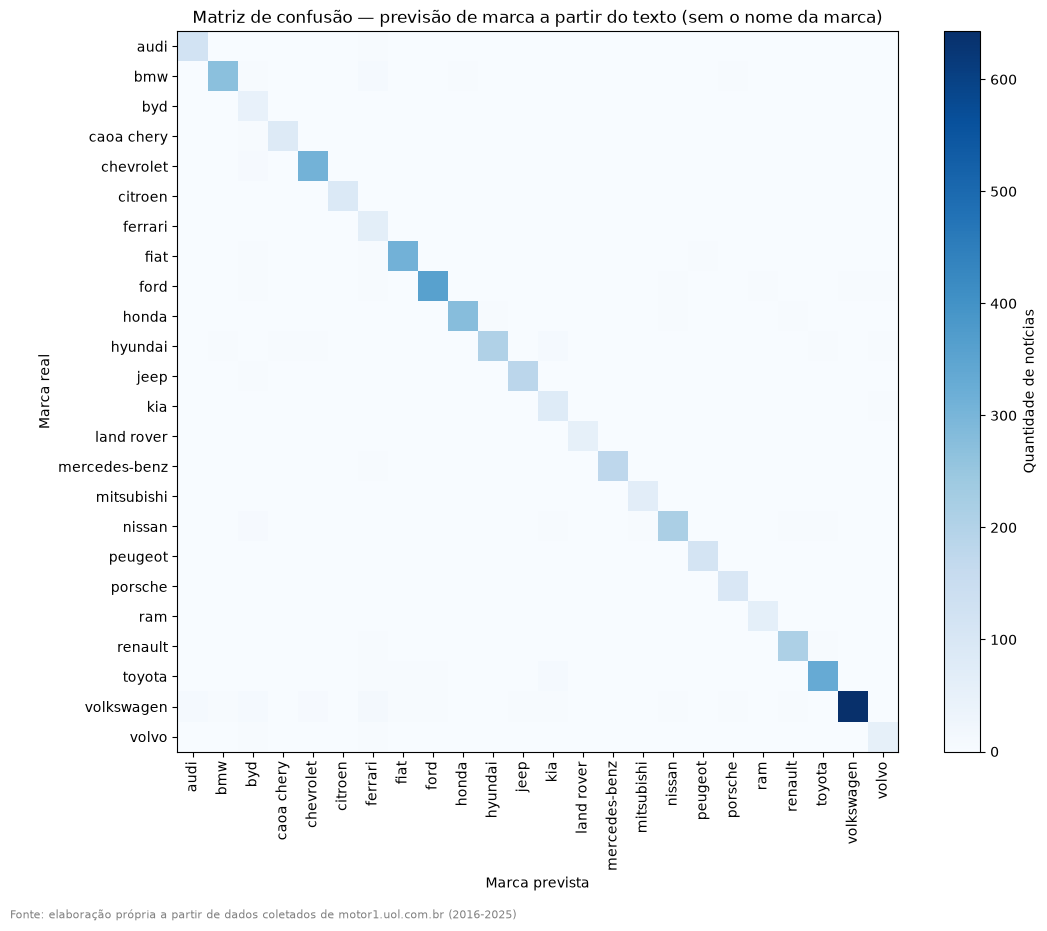

In [18]:
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_marca, cmap="Blues")
ax.set_xticks(range(len(clf_marca.classes_)))
ax.set_yticks(range(len(clf_marca.classes_)))
ax.set_xticklabels(clf_marca.classes_, rotation=90)
ax.set_yticklabels(clf_marca.classes_)
ax.set_xlabel("Marca prevista")
ax.set_ylabel("Marca real")
ax.set_title("Matriz de confusão — previsão de marca a partir do texto (sem o nome da marca)")
plt.colorbar(im, ax=ax, label="Quantidade de notícias")
fig.text(0.01, -0.02,
         "Fonte: elaboração própria a partir de dados coletados de motor1.uol.com.br (2016-2025)",
         fontsize=8, color="gray")
plt.tight_layout()
plt.show()


## B.8. Quais palavras identificam cada marca?

Mesmo sem o nome da marca, o modelo aprende a associar cada marca a nomes de modelo e jargão específico.


In [19]:
vocab_marca = np.array(vectorizer_marca.get_feature_names_out())

linhas_marca = []
for marca in marcas_validas:
    idx_classe = list(clf_marca.classes_).index(marca)
    top_idx = np.argsort(clf_marca.coef_[idx_classe])[::-1][:8]
    linhas_marca.append({
        "marca": marca,
        "n_noticias": int(contagem_marca[marca]),
        "f1_score": round(relatorio_marca[marca]["f1-score"], 3),
        "top_palavras": ", ".join(vocab_marca[top_idx]),
    })

df_palavras_marca = pd.DataFrame(linhas_marca).sort_values("f1_score")
df_palavras_marca


,marca,n_noticias,f1_score,top_palavras
23,byd,211,0.623,"song, dolphin, plus, shark, china, chinesa, ba..."
20,ferrari,271,0.674,"purosangue, v12, italiana, 488, 296, f1, carro..."
19,volvo,273,0.719,"xc90, xc40, xc60, geely, 950, seguranca, googl..."
16,kia,363,0.761,"sportage, stonic, rio, coreia, hyundai, sul, g..."
12,audi,546,0.851,"quattro, tron, q3, a3, tfsi, avant, q7, q5"
18,mitsubishi,302,0.876,"outlander, eclipse, triton, l200, pajero, niss..."
14,porsche,410,0.877,"911, cayenne, panamera, macan, taycan, 718, ca..."
7,nissan,996,0.879,"frontier, kicks, versa, sentra, leaf, march, g..."
8,hyundai,968,0.887,"creta, hb20, tucson, i30, ioniq, santa, elantr..."
22,land rover,246,0.891,"jaguar, defender, discovery, evoque, velar, sp..."


**Leitura da tabela:** marcas com F1 mais baixo tendem a ser as que menos dependem de nomes de modelo exclusivos e mais de vocabulário compartilhado com outras marcas do mesmo nicho — por exemplo, marcas menores e mais recentes no mercado brasileiro (como BYD) aparecem fortemente associadas a termos ligados a eletrificação (`bateria`, `eletrico`, `china`) que também aparecem em notícias de **outras** marcas quando o assunto é carro elétrico, o que gera mais falsos positivos para essas classes. Já marcas tradicionais com nomes de modelo muito específicos (Jeep → `compass`, `renegade`, `wrangler`; Ferrari → `v12`, `purosangue`, `488`) são identificadas com muito mais precisão.


In [20]:
ARQUIVO_SAIDA_MARCA = os.path.join(DATA_DIR, "classificacao_marca_resultado.csv")
df_palavras_marca.to_csv(ARQUIVO_SAIDA_MARCA.replace(".csv", "_top_palavras.csv"), index=False)
df_relatorio_marca.to_csv(ARQUIVO_SAIDA_MARCA.replace(".csv", "_metricas.csv"))
df_confusoes_marca.to_csv(ARQUIVO_SAIDA_MARCA.replace(".csv", "_confusoes.csv"), index=False)
print("Tabelas salvas.")


Tabelas salvas.


## Conclusão da Seção B

- Removendo o nome da marca do texto, um modelo simples ainda acerta a marca em **~90%** dos casos (F1 macro ≈ 0,88) — muito acima do baseline de ~15%. Isso confirma que cada marca tem uma "assinatura" de vocabulário própria no jornalismo automotivo: nomes de modelo, categorias de veículo mais associadas a ela, e até o país/região de origem.
- As marcas com pior desempenho (BYD, Ferrari, Volvo, Kia) são, em geral, marcas de nicho ou em expansão recente no Brasil, cujo vocabulário se sobrepõe ao de outras marcas do mesmo segmento (elétricos, esportivos de luxo, ou economia emergente) — não é uma falha do método, é um reflexo real de como essas marcas são cobertas de forma mais genérica ou temática do que por identidade de modelo.
- Diferente da Seção A, este resultado não valida nenhuma etapa anterior do projeto — é um achado complementar que reforça, de outro ângulo, algo que a Etapa 3 já vinha sugerindo: a cobertura de imprensa sobre marcas tem um vocabulário temático forte (elétrico, híbrido, categoria de veículo) que às vezes pesa mais do que a identidade da própria marca.


---
## Conclusão Geral da Etapa 4

- **Cluster (Seção A):** ~97% de acurácia confirma que os clusters da Etapa 2 são regiões coesas e bem separáveis no espaço de vocabulário — a lista de termos que a Etapa 2 usou para "rotular" cada cluster bate com o que a Regressão Logística aprendeu de forma independente. Com a ressalva de que isso não é uma validação totalmente externa, já que ambos os métodos partem do mesmo tipo de representação de texto (TF-IDF).
- **Marca (Seção B):** ~90% de acurácia, mesmo removendo o nome da marca do texto, mostra que a cobertura jornalística tem uma "assinatura" vocabular forte por marca — mas essa assinatura é mais fraca justamente nas marcas mais associadas ao tema central deste projeto (elétrico/híbrido), como BYD, o que é coerente com a ideia de que o vocabulário de "transição elétrica" atravessa marcas, não fica preso a uma só.
- Voltando à pergunta-guia do projeto: esta etapa não mede diretamente se a cobertura antecipou ou acompanhou a transição elétrica, mas fortalece a confiança nos resultados das etapas anteriores (Etapa 2 e Etapa 3) que sustentam essa conclusão, mostrando que os padrões encontrados ali não são artefatos frágeis dos algoritmos não supervisionados.
